## Résolution par PINN (PyTorch)

Dans cette partie, nous utilisons un **Physics-Informed Neural Network (PINN)** implémenté avec **PyTorch** afin d'obtenir une approximation numérique de la solution du problème de conduction thermique.

Contrairement à la méthode des éléments finis, le PINN ne repose pas sur un maillage. Le réseau de neurones est entraîné en minimisant une fonction de perte construite à partir de l'équation aux dérivées partielles ainsi que des conditions aux limites de Dirichlet.

Le problème considéré est

$$
\begin{cases}
-\nabla \cdot \left(k(x,y)\nabla u\right)=1000, & \text{dans } \Omega,\\[4pt]
u=0, & \text{sur } \partial\Omega,
\end{cases}
$$

avec

$$
\Omega=(0,1)\times(0,1)\subset\mathbb{R}^{2},
$$

et

$$
k(x,y)=
\begin{cases}
205,& x<0.5,\\
50,& x\ge0.5.
\end{cases}
$$

Le réseau est entraîné à approximer directement la température \(u(x,y)\) en satisfaisant les lois physiques imposées par l'équation différentielle.

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/karimchibani/data-matlab/solution_matlab_direct.csv


In [3]:
df_matlab = pd.read_csv('/kaggle/input/datasets/karimchibani/data-matlab/solution_matlab_direct.csv')
df_matlab.head()

,X,Y,U_matlab
0,0.0,0.000,0.000000e+00
1,0.0,0.025,-7.793563e-18
2,0.0,0.050,1.861887e-15
3,0.0,0.075,-6.775433e-16
4,0.0,0.100,-3.186686e-14


In [4]:
df_matlab.shape

(1681, 3)

In [18]:
#1. model.py#
import torch
import torch.nn as nn

class PINN(nn.Module):
    def __init__(self):
        super(PINN, self).__init__()
        # Réseau de neurones fully-connected avec 4 couches cachées
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )
        
    def forward(self, x, y):
        X = torch.cat([x, y], dim=1)
        u_nn = self.net(X)
        # Imposition exacte des conditions de Dirichlet homogènes (u = 0 sur les bords)
        return x * (1.0 - x) * y * (1.0 - y) * u_nn

In [19]:
#2. loss.py#
import torch

def calculer_loss_pde(model, x, y):
    # Évaluation du modèle
    u = model(x, y)
    
    # Calcul des dérivées premières par autograd (du/dx et du/dy)
    du_dx = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    du_dy = torch.autograd.grad(u, y, torch.ones_like(u), create_graph=True)[0]
    
    # Conductivité thermique k(x,y) : 205 si x < 0.5, sinon 50
    k = torch.where(x < 0.5, torch.tensor(205.0), torch.tensor(50.0))
    
    # Composantes du flux thermique : k * grad(u)
    flux_x = k * du_dx
    flux_y = k * du_dy
    
    # Divergence du flux : div(k * grad(u))
    dflux_x_dx = torch.autograd.grad(flux_x, x, torch.ones_like(flux_x), create_graph=True)[0]
    dflux_y_dy = torch.autograd.grad(flux_y, y, torch.ones_like(flux_y), create_graph=True)[0]
    
    # Forme forte de l'EDP : -div(k*grad(u)) - 1000 = 0
    residu = - (dflux_x_dx + dflux_y_dy) - 1000.0
    return torch.mean(residu ** 2)

In [20]:
import torch.optim as optim

def entrainer(model, x, y):
    optimizer_adam = optim.Adam(model.parameters(), lr=0.001)
    optimizer_lbfgs = optim.LBFGS(
        model.parameters(), 
        lr=0.5, 
        max_iter=1500, 
        line_search_fn="strong_wolfe"
    )
    
    print("--- Phase 1 : Adam ---")
    for epoch in range(6000):
        optimizer_adam.zero_grad()
        loss = calculer_loss_pde(model, x, y)  # استخدام الدالة المباشرة بدون import
        loss.backward()
        optimizer_adam.step()
        
        if epoch % 1000 == 0:
            print(f"Époque {epoch:4d} | Perte PDE : {loss.item():.4e}")

    print("\n--- Phase 2 : L-BFGS ---")
    def closure():
        optimizer_lbfgs.zero_grad()
        loss = calculer_loss_pde(model, x, y)
        loss.backward()
        return loss

    optimizer_lbfgs.step(closure)
    print("Entraînement terminé avec succès !")

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm

def predire_et_afficher(model):
    model.eval()
    x_espace = np.linspace(0, 1, 100)
    y_espace = np.linspace(0, 1, 100)
    X_mesh, Y_mesh = np.meshgrid(x_espace, y_espace)

    x_tensor = torch.tensor(X_mesh.flatten(), dtype=torch.float32).view(-1, 1)
    y_tensor = torch.tensor(Y_mesh.flatten(), dtype=torch.float32).view(-1, 1)

    with torch.no_grad():
        U_PINN = model(x_tensor, y_tensor).numpy().reshape(X_mesh.shape)

    # Affichage 2D
    plt.figure(figsize=(6, 5))
    plt.contourf(X_mesh, Y_mesh, U_PINN, levels=50, cmap='viridis')
    plt.colorbar(label='u(x,y)')
    plt.axvline(x=0.5, color='white', linestyle=':', label='Interface X=0.5')
    plt.title("Solution 2D - PINN")
    plt.legend()
    plt.show()

    # Affichage 3D
    fig = plt.figure(figsize=(7, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(X_mesh, Y_mesh, U_PINN, cmap=cm.viridis)
    ax.set_title("Solution 3D - PINN")
    plt.show()

--- Phase 1 : Adam ---
Époque    0 | Perte PDE : 9.9502e+05
Époque 1000 | Perte PDE : 3.2586e+05
Époque 2000 | Perte PDE : 2.3418e+04
Époque 3000 | Perte PDE : 7.1650e+03
Époque 4000 | Perte PDE : 4.4550e+03
Époque 5000 | Perte PDE : 2.9993e+03

--- Phase 2 : L-BFGS ---
Entraînement terminé avec succès !


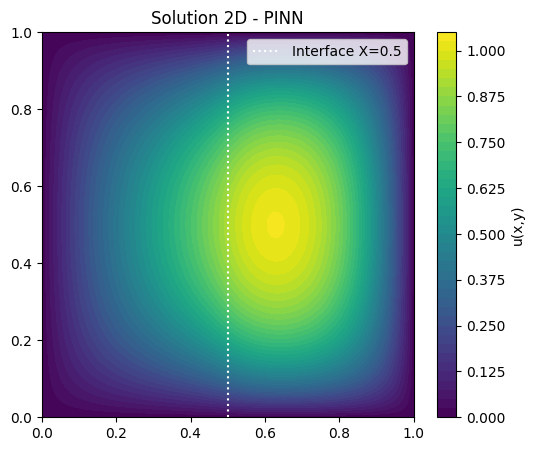

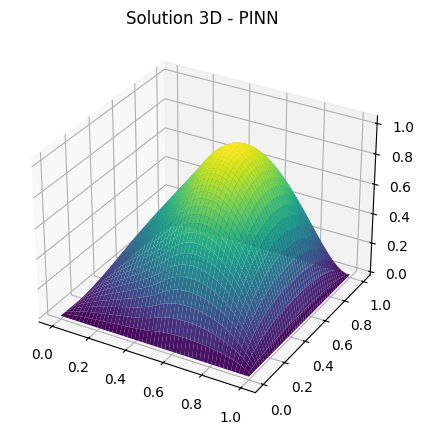

In [29]:
# 1. Génération des points
x_uniforme = torch.rand(5000, 1)
y_uniforme = torch.rand(5000, 1)

x_dense = torch.clamp(0.5 + 0.08 * torch.randn(1500, 1), 0.0, 1.0)
y_dense = torch.rand(1500, 1)

x = torch.cat([x_uniforme, x_dense], dim=0)
y = torch.cat([y_uniforme, y_dense], dim=0)
x.requires_grad = True
y.requires_grad = True

# 2. Modèle & Entraînement
model = PINN()
entrainer(model, x, y)

# 3. Prédiction
predire_et_afficher(model)
                    

In [ ]:

print("Valeur maximale (PINN) =", float(model(x, y).max().item()))

Valeur maximale (PINN) = 1.0288124084472656


In [46]:
#_____________________________________________ERREUR RELATIVE GLOBALE L2_________________________________#
import pandas as pd
import numpy as np
import torch

# =========================================================================
# 1. Génération des prédictions du PINN sur la même grille
# =========================================================================
# Chargement du DataFrame MATLAB depuis Kaggle
df_matlab = pd.read_csv('/kaggle/input/datasets/karimchibani/data-matlab/solution_matlab_direct.csv')

# Extraction des coordonnées X, Y et du vecteur de solution FEM
x_fem = df_matlab['X'].values
y_fem = df_matlab['Y'].values
U_FEM = df_matlab['U_matlab'].values

# Conversion des coordonnées en tenseurs PyTorch pour le PINN
x_tensor = torch.tensor(x_fem, dtype=torch.float32).view(-1, 1)
y_tensor = torch.tensor(y_fem, dtype=torch.float32).view(-1, 1)

# Prédiction de la solution PINN aux mêmes points (X, Y)
model.eval()
with torch.no_grad():
    U_PINN_flat = model(x_tensor, y_tensor).numpy().flatten()

# =========================================================================
# 2. Calcul de l'erreur relative globale L2
# =========================================================================
norme_difference = np.linalg.norm(U_FEM - U_PINN_flat)
norme_fem = np.linalg.norm(U_FEM)

erreur_l2 = norme_difference / norme_fem

print("=" * 50)
print(f"--> ERREUR RELATIVE GLOBALE L2 : {erreur_l2 * 100:.2f} %")
print("=" * 50)

--> ERREUR RELATIVE GLOBALE L2 : 30.83 %


--- Début de l'étude de convergence temporelle ---
Époque    0 | Perte PDE : 1.0079e+06
Époque 1000 | Perte PDE : 3.2580e+05
Époque 2000 | Perte PDE : 1.7404e+04
Époque 3000 | Perte PDE : 9.3464e+03
Époque 4000 | Perte PDE : 8.0306e+03
Époque 5000 | Perte PDE : 4.4672e+03
Époque 6000 | Perte PDE : 4.2027e+03


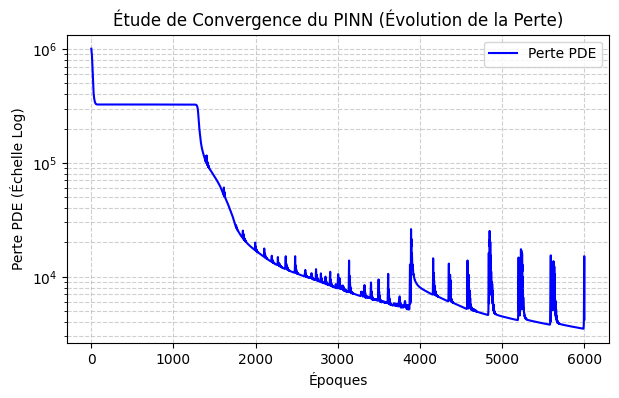

In [47]:
#_________________________________________________Étude de Convergence du PINN_________________________________________
import matplotlib.pyplot as plt
import torch
import torch.optim as optim

# 1. Initialisation du modèle et de l'optimiseur
model_conv = PINN()
optimizer_adam = optim.Adam(model_conv.parameters(), lr=0.001)

historique_loss = []

print("--- Début de l'étude de convergence temporelle ---")
for epoch in range(6001):
    optimizer_adam.zero_grad()
    loss = calculer_loss_pde(model_conv, x, y)
    loss.backward()
    optimizer_adam.step()

    historique_loss.append(loss.item())

    if epoch % 1000 == 0:
        print(f"Époque {epoch:4d} | Perte PDE : {loss.item():.4e}")

# 2. Tracé de la courbe de convergence
plt.figure(figsize=(7, 4))
plt.plot(historique_loss, color="blue", label="Perte PDE")
plt.yscale("log")  # Échelle logarithmique pour une meilleure lisibilité
plt.xlabel("Époques")
plt.ylabel("Perte PDE (Échelle Log)")
plt.title("Étude de Convergence du PINN (Évolution de la Perte)")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.legend()
plt.show()